# 1A: Code & Answers

In [1]:
# main imports
import pandas as pd
import numpy as np

In [2]:
# import CSV and dictionary
import gdown
csv_id = '1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH'
dict_id = '1GKbh50b-NexKtv-47-y4VP1kklBIvX5p'

gdown.download(id=csv_id,output='co_occur.csv')
gdown.download(id=dict_id,output='dictionary.txt')

Downloading...
From (original): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH
From (redirected): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH&confirm=t&uuid=4caad3a6-1e07-4e76-aba6-71bb05be7d9d
To: C:\Users\ayaan\Desktop\VS Code Parent\svd\co_occur.csv
100%|██████████| 281M/281M [00:06<00:00, 45.0MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1GKbh50b-NexKtv-47-y4VP1kklBIvX5p
To: C:\Users\ayaan\Desktop\VS Code Parent\svd\dictionary.txt
100%|██████████| 79.3k/79.3k [00:00<00:00, 5.05MB/s]


'dictionary.txt'

In [3]:
# import matrix and dictionary
M = pd.read_csv('co_occur.csv',header=None).values

with open('dictionary.txt','r') as d:
    dictionary = d.read().splitlines()

print("Matrix shape:", M.shape)
print("First 10 words in dictionary:", dictionary[:10])

Matrix shape: (10000, 10000)
First 10 words in dictionary: ['the', 'of', 'in', 'and', 'to', 'was', 'is', 'for', 'on', 'as']


# 1B: Code & Answers

In [4]:
# import
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds

# normalize the matrix
M_norm = np.log(1 + M)

# get SVDs in descending order
U, S, V_T = svds(M_norm, k=100) #ascending order so we need to reverse
U = U[:, ::-1] #reverse columns
S = S[::-1] #reverse array
V_T = V_T[::-1, :] #reverse rows

# save the SVD
np.savez('rank-100-svd',U=U,S=S,V_T=V_T)

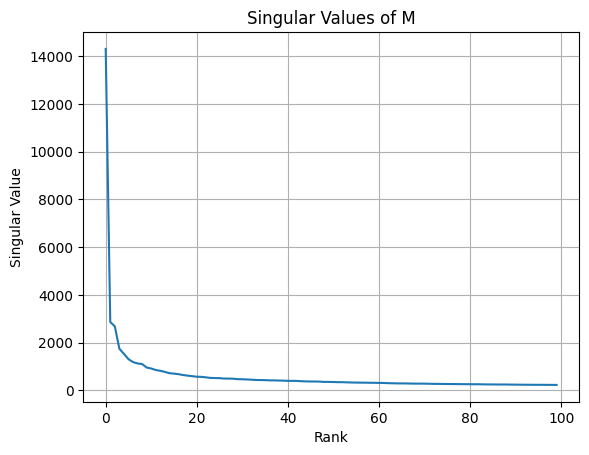

In [5]:
# plot the singular values
plt.plot(S)
plt.title('Singular Values of M')
plt.xlabel('Rank')
plt.ylabel('Singular Value')
plt.grid(True)
plt.show()

### Answer to Question 1B:

M seems to be a low-rank matrix, as the singular values drop of significantly after the first few ranks. We can see this from the graph, where the singular values rapidly decrease, reaching under 2000 before rank 5.

# 1C: Code & Answers

In [6]:
# iterate through the 10 most important singular vectors
for i in range(10):
    # assign the singular vector
    v_i = U[:, i]
    v_indices = np.argsort(v_i)

    # take the 10 most positive and negative values
    pos_idx = v_indices[::-1][:10]
    neg_idx = v_indices[:10]
    pos_words = [dictionary[idx] for idx in pos_idx]
    neg_words = [dictionary[idx] for idx in neg_idx]
    
    print(f"Rank {i} --> Singular Value = {S[i]}")
    print("Most Positive Words:", pos_words)
    print("Most Negative Words:", neg_words)

    print()

Rank 0 --> Singular Value = 14299.743065022361
Most Positive Words: ['gmina', 'insee', 'householder', 'increment', 'peakposition', 'midst', 'outskirts', 'iucn', 'voivodeship', 'subtropical']
Most Negative Words: ['the', 'and', 'of', 'in', 'to', 'for', 'as', 'is', 'with', 'was']

Rank 1 --> Singular Value = 2864.8156015105565
Most Positive Words: ['the', 'and', 'of', 'in', 'to', 'for', 'with', 'as', 'by', 'is']
Most Negative Words: ['innings', 'tournaments', 'leagues', 'constituency', 'medals', 'locomotives', 'households', 'manga', 'billboard', 'theaters']

Rank 2 --> Singular Value = 2682.6537863979947
Most Positive Words: ['specific', 'any', 'data', 'provide', 'these', 'certain', 'different', 'systems', 'its', 'use']
Most Negative Words: ['born', 'john', 'james', 'david', 'robert', 'william', 'jr', 'george', 'thomas', 'michael']

Rank 3 --> Singular Value = 1745.554920209624
Most Positive Words: ['you', 'album', 'love', 'me', 'my', 'song', 'episode', 'your', 'vocals', 'baby']
Most Neg

### Answer to Question 1C:

#### 5 Interpretable Singular Vectors
- **Rank 1 Singular Vector**
  - Most Positive Words: `['innings', 'tournaments', 'leagues', 'constituency', 'medals', 'locomotives', 'households', 'manga', 'billboard', 'theaters']`
  - Most Negative Words: `['the', 'and', 'of', 'in', 'to', 'for', 'with', 'as', 'by', 'is']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with very specific niches (like sports, entertainment, etc.), which have very positive values, with vocabulary that is very generic (function words liks `the` and `of`), which have very negative values.*
- **Rank 2 Singular Vector**
  - Most Positive Words: `['born', 'john', 'james', 'david', 'robert', 'william', 'jr', 'george', 'thomas', 'michael']`
  - Most Negative Words: `['specific', 'any', 'data', 'provide', 'these', 'certain', 'different', 'systems', 'its', 'use']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with names (like `john` and `jr`), which have very positive values, with vocabulary more associated with research and/or formal wording (like `data` and `systems`), which have very negative values.*
- **Rank 4 Singular Vector**
  - Most Positive Words: `['jpg', 'km', 'located', 'near', 'road', 'river', 'lake', 'route', 'station', 'mountain']`
  - Most Negative Words: `['political', 'social', 'religious', 'law', 'legal', 'policy', 'rights', 'government', 'minister', 'jewish']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with location-based or physical ideas (like `km` or `lake`), which have very positive values, with vocabulary associated with governance, religion, or artificial ideas (like `religious` or `law`), which have very negative values.*
- **Rank 5 Singular Vector**
  - Most Positive Words: `['troops', 'him', 'killed', 'soldiers', 'they', 'them', 'were', 'had', 'emperor', 'attacked']`
  - Most Negative Words: `['digital', 'science', 'software', 'technology', 'engineering', 'computer', 'research', 'online', 'web', 'electronic']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with war (like `troops` and `killed`), which have very positive values, with vocabulary more associated with technology (like `digital` and `software`), which have very negative values.*
- **Rank 7 Singular Vector**
  - Most Positive Words: `['took', 'gave', 'brought', 'led', 'joined', 'served', 'moved', 'came', 'became', 'entered']`
  - Most Negative Words: `['him', 'them', 'it', 'himself', 'her', 'students', 'who', 'government', 'people', 'players']`
  - Semantic/Syntatic Structure: *The vector contrasts past-tense action verbs (like `took` and `led`), which have very positive values, with pronouns (like `him` or `it`), which have very negative values.*


#### Why not all of the singular vectors have easy-to-interpret semantics:
I think that not all the singular vectors have easy-to-interpret semantics because they are solely there to explain the variance in the data. Since they do not specifically look for semantic coherence (which humans look for, as we tend to look for words that would work well together logically), there were some cases where the vectors were used to explain variance, but we couldn't really interpret why, because it wasn't explaining the semantic coherence that we look for. An example of this was the `Rank 0 Singular Vector`, for which the most positive words (`['the', 'and', 'of', 'in', 'to', 'for', 'as', 'is', 'with', 'was']`) were very generic function words, but the most negative words were seemingly random words that we don't write with a lot (`['gmina', 'insee', 'householder', 'increment', 'peakposition', 'midst', 'outskirts', 'iucn', 'voivodeship', 'subtropical']`). Other than that, there was not really any relationship between the words, causing difficulty in interpretation, despite the vector well explaining the variance.

# 1D: Code & Answers

In [7]:
# normalize each row of U
for i in range(len(U)):
    norm = np.linalg.norm(U[i])
    U[i] = U[i] / norm

In [8]:
# function to find embeddings of specific words
def find_embedding(word):
    idx = dictionary.index(word)
    return U[idx]

# define vector v
v1 = find_embedding("woman")
v2 = find_embedding("man")
v = v1 - v2

## 1D (i)

In [9]:
# gets the scalar projection of a given word on a given vector
def get_projection(word, vector):
    embedding = find_embedding(word)
    dotP = np.dot(embedding, vector)
    mag = np.linalg.norm(vector)
    return dotP / mag

# get the projections for the given words
words = ['boy','girl','brother','sister','king','queen','he','she','john','mary','wall','tree']
projections = [get_projection(word, v) for word in words]

In [10]:
# import
import plotly.express as px
import plotly.io as pio

# create the plot & fix UI
fig = px.scatter(x=projections, y=np.zeros_like(projections), text=words)
fig.update_traces(textposition="top center")
fig.update_yaxes(visible=False)
fig.update_layout(showlegend=False, height=200)

# draw the plot
pio.renderers.default = "notebook_connected"
fig.show()

### Answer to 1D (i)

It seems like the words more associated with `men` are more negative, and the words more associated with `women` are more positive, as expected. We can see that the neutral word `tree` stayed in the middle, due to its gender neutrality, while words like `girl` and `mary` (which are more feminine) are positive and words like `boy` and `john` (which are more masculine) are negative. This aligns with the original vector in which `women` was the positive and `men` was negative (v = v1 - v2).

## 1D (ii)

In [12]:
# import
import plotly.express as px
import plotly.io as pio

# get the projections for the given words
words = ['math','matrix','history','nurse','doctor','pilot','teacher','engineer','science','arts','literature','bob','alice']
projections = [get_projection(word, v) for word in words]

# create the plot & fix UI
fig = px.scatter(x=projections, y=np.zeros_like(projections), text=words)
fig.update_traces(textposition="top center")
fig.update_yaxes(visible=False)
fig.update_layout(showlegend=False, height=200)

# draw the plot
pio.renderers.default = "notebook_connected"
fig.show()

### Answer to 1D (ii)

It seems that the vector space affirms long-standing stereotypes of certain professions and/or other things that correlate to men or women. We can see that `engineer` is heavily negative, while `nurse` is heavily positive, despite both jobs being open to both genders. Additionally, words like `math`, `doctor`, and `pilot` are more masculine, while words like `teacher` and `arts` are more feminine, indicating a bias to long-standing stereotypes that may not really show the true correlation between how words should be used. This could be an issue, as if new systems use these embeddings to search for job candidates, these stereotypes will be further reaffirmed, despite an overarching societal goal of gender equality, especially in the workplace.

### Answer to 1D (iii)

One way to help mitigate the problem discussed in part 1D (ii) is to identify and project gender neutral words onto a plane that is orthogonal from gender-based words. This would remove any gender-bias in the embeddings for these words, causing them to have a projection of `0` on vector v.